## DQN for CartPole in Gymnasium

In [1]:
import numpy as np 
import gymnasium as gym 
import matplotlib.pyplot as plt 
import os, pickle, sys, torch, random
from collections import namedtuple, deque 
from itertools import count
from IPython.display import clear_output

import torch.nn as nn 
import torch.nn.functional as F 

%matplotlib inline 

In [2]:
resultsPath = os.path.join('results', 'R1_DQN_cartpole')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath) 

In [3]:
if torch.cuda.is_available():
    print('GPU available')
    device = 'cuda'
else:
    print('only CPU available')
    device = 'cpu'
device 

GPU available


'cuda'

In [4]:
env = gym.make('CartPole-v1')

In [5]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward')) 

In [6]:
class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity) 

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory) 

In [7]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        output = F.relu(self.layer1(x)) 
        output = F.relu(self.layer2(output)) 
        return self.layer3(output) 

In [8]:
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4

In [9]:
# reset environment to start a new episode 
state, info = env.reset() 
# state: what the agent can see -- cart position, velocity, pole angle, etc
# info: extra debugging info (usually not needed for basic learning)

In [10]:
state

array([ 0.01441024, -0.01340448,  0.01048736, -0.02799133], dtype=float32)

In [11]:
info 

{}

In [12]:
n_observations = len(state)
n_observations

4

In [13]:
# total number of actions in the space 
n_actions = env.action_space.n 
n_actions 

np.int64(2)

In [14]:
policy_net = DQN(n_observations=n_observations, n_actions=n_actions).to(device)
target_net = DQN(n_observations=n_observations, n_actions=n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
policy_net 

DQN(
  (layer1): Linear(in_features=4, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=2, bias=True)
)

In [15]:
torch.tensor([state, state])

/tmp/ipykernel_294453/1370302558.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /tmp/build_wheels_tmp.6038/python-3.12/torch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor([state, state])


tensor([[ 0.0144, -0.0134,  0.0105, -0.0280],
        [ 0.0144, -0.0134,  0.0105, -0.0280]])

In [16]:
output = policy_net(torch.tensor([state, state]).to(device))
output 

tensor([[-0.0409, -0.0051],
        [-0.0409, -0.0051]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [17]:
optimizer = torch.optim.AdamW(params=policy_net.parameters(), lr=LR, amsgrad=True) 
memory = ReplayMemory(10000)

In [18]:
steps_done = 0 
episode_durations = []

In [19]:
def select_action(state):
    global steps_done 
    rand_sample = random.random()    # random sample [0, 1) 
    eps_threshold = EPS_END + (EPS_START - EPS_END) * np.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    
    if rand_sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(dim=1).indices.view((1, 1)) 
    else:
        return torch.tensor([[env.action_space.sample()]], device=device) 

In [20]:
select_action(state)

tensor([[1]], device='cuda:0')

In [21]:
def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated

    if not show_result:
        display(plt.gcf())
        clear_output(wait=True)
    else:
        display(plt.gcf())

In [22]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return 

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()    

Complete


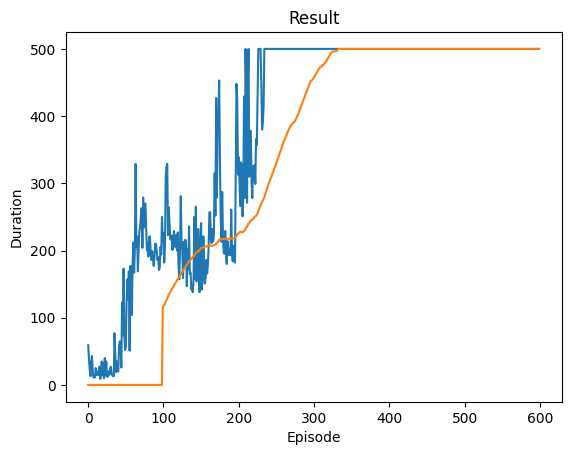

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [23]:
num_episodes = 600

plt.ion()

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()


In [24]:
PTH_trained_model = os.path.join(resultsPath, f'DQN_policy_net.pth')
torch.save(policy_net.state_dict(), PTH_trained_model) 

In [25]:
PTH_trained_model = os.path.join(resultsPath, f'DQN_target_net.pth')
torch.save(target_net.state_dict(), PTH_trained_model) 